# LSTM Time-Series Forecasting Kualitas Udara

## Library dan Seed yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

## Mengimport Dataset

In [2]:
df = pd.read_csv('data_kualitas_udara.csv')
df.head()

,id,waktu,suhu,kelembaban,debu,gas_mq7,gas_mq135,kondisi
0,1784009995,2026-07-14 13:19:55,26.5,48.9,34,158,101,Baik
1,1784010057,2026-07-14 13:20:57,26.5,49.0,35,154,97,Baik
2,1784010118,2026-07-14 13:21:58,26.6,49.4,35,180,119,Baik
3,1784010180,2026-07-14 13:23:00,26.6,49.4,37,159,98,Baik
4,1784010241,2026-07-14 13:24:01,26.6,49.5,37,161,99,Baik


## Mengecek Jumlah dan Tipe Data

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          100 non-null    int64  
 1   waktu       100 non-null    object 
 2   suhu        100 non-null    float64
 3   kelembaban  100 non-null    float64
 4   debu        100 non-null    int64  
 5   gas_mq7     100 non-null    int64  
 6   gas_mq135   100 non-null    int64  
 7   kondisi     100 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 6.4+ KB
None


## Mengubah Tipe Data Kolom Waktu dan Mengurutkannya Berdasarkan Waktu Terlama

In [4]:
df["waktu"] = pd.to_datetime(df["waktu"])
df = df.sort_values("waktu")
df.reset_index(drop=True, inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          100 non-null    int64         
 1   waktu       100 non-null    datetime64[ns]
 2   suhu        100 non-null    float64       
 3   kelembaban  100 non-null    float64       
 4   debu        100 non-null    int64         
 5   gas_mq7     100 non-null    int64         
 6   gas_mq135   100 non-null    int64         
 7   kondisi     100 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 6.4+ KB
None


## Mengecek Missing Value

In [5]:
print("\nMissing Value")
print(df.isnull().sum())

print("\nData Duplikat :", df.duplicated().sum())


Missing Value
id            0
waktu         0
suhu          0
kelembaban    0
debu          0
gas_mq7       0
gas_mq135     0
kondisi       0
dtype: int64

Data Duplikat : 0


## Mengecek Outlier

HASIL DETEKSI OUTLIER (METODE IQR)
    Parameter      Q1      Q3    IQR  Batas Bawah  Batas Atas  Jumlah Outlier
0        debu   26.00   35.25   9.25        12.12       49.12               3
1        suhu   26.70   33.00   6.30        17.25       42.45               0
2  kelembaban   50.00   63.90  13.90        29.15       84.75               0
3     gas_mq7  126.50  160.00  33.50        76.25      210.25               6
4   gas_mq135   93.75  103.00   9.25        79.88      116.88              15


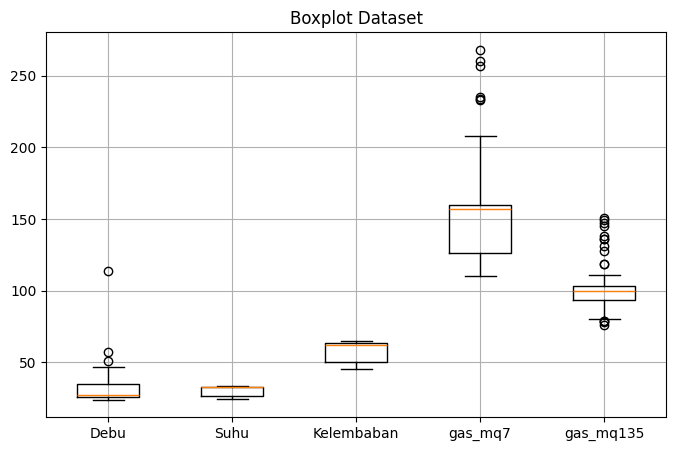

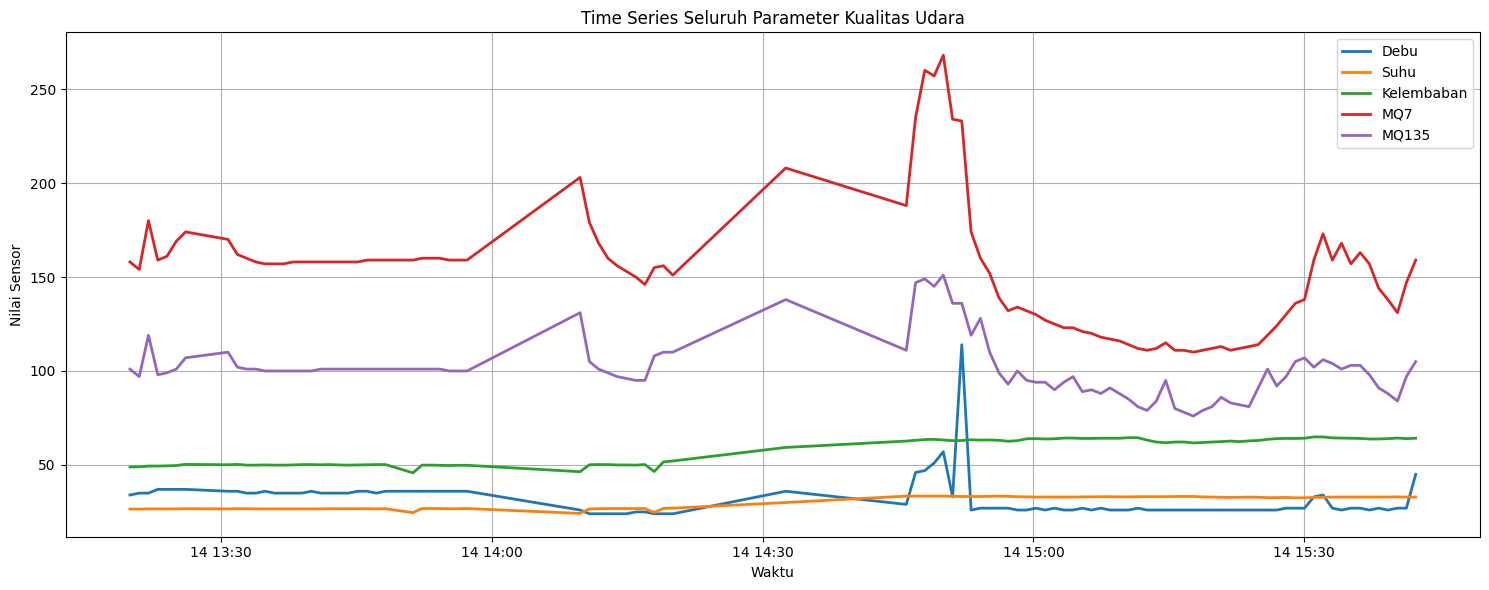

In [10]:
fitur = ["debu", "suhu", "kelembaban", "gas_mq7", "gas_mq135"]

hasil = []

for kolom in fitur:

    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[kolom] < lower) | (df[kolom] > upper)]

    hasil.append([
        kolom,
        round(Q1,2),
        round(Q3,2),
        round(IQR,2),
        round(lower,2),
        round(upper,2),
        len(outlier)
    ])

hasil = pd.DataFrame(
    hasil,
    columns=[
        "Parameter",
        "Q1",
        "Q3",
        "IQR",
        "Batas Bawah",
        "Batas Atas",
        "Jumlah Outlier"
    ]
)

print("="*80)
print("HASIL DETEKSI OUTLIER (METODE IQR)")
print("="*80)

print(hasil)

plt.figure(figsize=(8,5))

plt.boxplot([
    df["debu"],
    df["suhu"],
    df["kelembaban"],
    df["gas_mq7"],
    df["gas_mq135"]
])

plt.xticks(
    [1,2,3,4,5],
    ["Debu","Suhu","Kelembaban", "gas_mq7", "gas_mq135"]
)

plt.title("Boxplot Dataset")

plt.grid(True)

plt.show()

df["waktu"] = pd.to_datetime(df["waktu"])

plt.figure(figsize=(15,6))

plt.plot(df["waktu"], df["debu"], label="Debu", linewidth=2)
plt.plot(df["waktu"], df["suhu"], label="Suhu", linewidth=2)
plt.plot(df["waktu"], df["kelembaban"], label="Kelembaban", linewidth=2)
plt.plot(df["waktu"], df["gas_mq7"], label="MQ7", linewidth=2)
plt.plot(df["waktu"], df["gas_mq135"], label="MQ135", linewidth=2)

plt.title("Time Series Seluruh Parameter Kualitas Udara")
plt.xlabel("Waktu")
plt.ylabel("Nilai Sensor")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Pemilihan Fitur dan Normalisasi Data

In [11]:
features=['suhu','kelembaban','debu','gas_mq7','gas_mq135']

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

## Pembentukan Data Sekuens Menggunakan Sliding Window

In [12]:
window = 60

X = []
y = []

for i in range(window, len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(40, 60, 5)
(40, 5)


## Split Data Training dan Testing

In [13]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

## LSTM

In [14]:
model = Sequential([Input(shape=(60,5)),LSTM(64,return_sequences=True),Dropout(0.2),LSTM(32),Dense(16,activation='relu'),Dense(5)])
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(X_train,y_train,epochs=20,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.3833 - mae: 0.4652 - val_loss: 0.3822 - val_mae: 0.4653
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.3602 - mae: 0.4220 - val_loss: 0.3637 - val_mae: 0.4406
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.3514 - mae: 0.4229 - val_loss: 0.3505 - val_mae: 0.4247
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.3417 - mae: 0.4240 - val_loss: 0.3356 - val_mae: 0.4128
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.3315 - mae: 0.4196 - val_loss: 0.3211 - val_mae: 0.4058
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.3199 - mae: 0.4148 - val_loss: 0.3079 - val_mae: 0.4012
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.3038 - mae: 0.4020 - val_loss: 0.2944 - val_mae: 0.3973
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.2901 - mae: 0.3895 - val_loss: 0.2819 - val_mae: 0.3941
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.2739 - mae: 0.3

## Evaluasi Hasil

HASIL EVALUASI REGRESI

Debu
MAE  : 1.6687
MSE  : 2.7860
RMSE : 1.6691
R²   : -2546.2356

Suhu
MAE  : 5.0981
MSE  : 26.0192
RMSE : 5.1009
R²   : -866.3062

Kelembaban
MAE  : 23.0393
MSE  : 568.0724
RMSE : 23.8343
R²   : -14.4578

Gas_MQ7
MAE  : 34.5074
MSE  : 1302.8681
RMSE : 36.0953
R²   : -10.6328

Gas_MQ135
MAE  : 6.3708
MSE  : 52.0686
RMSE : 7.2159
R²   : 0.0008


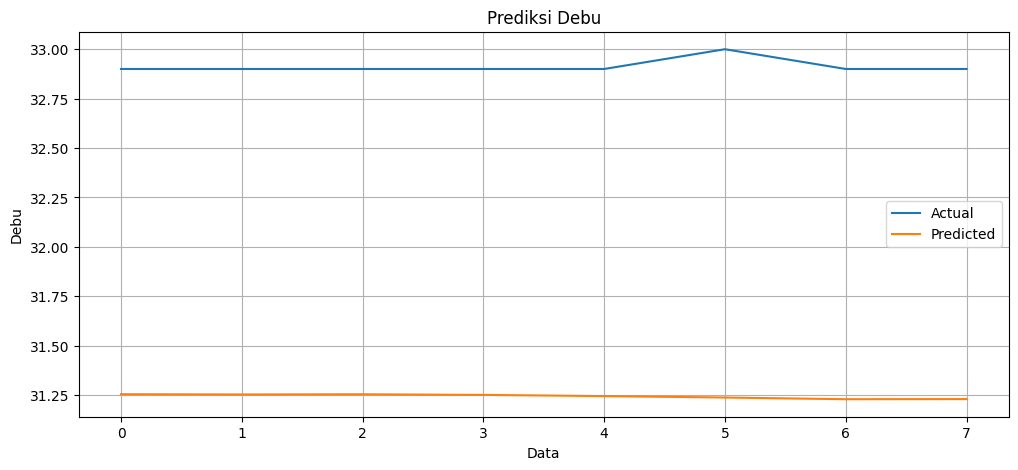

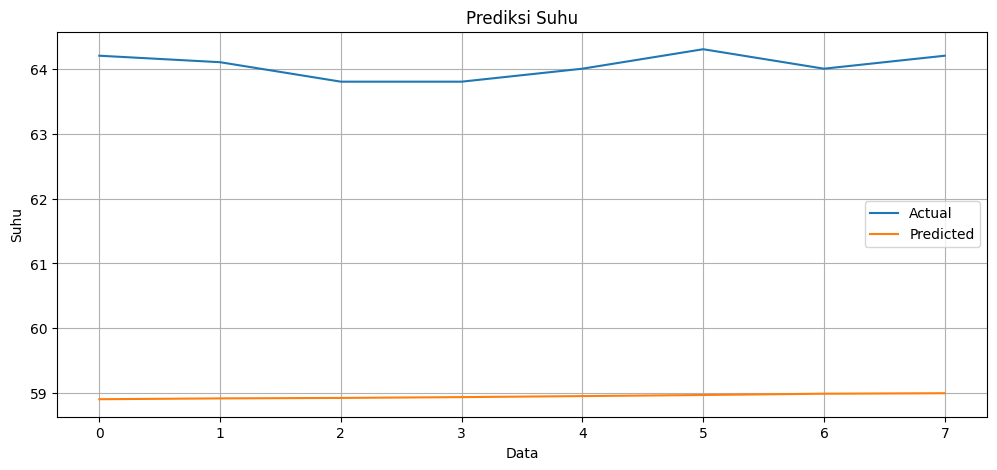

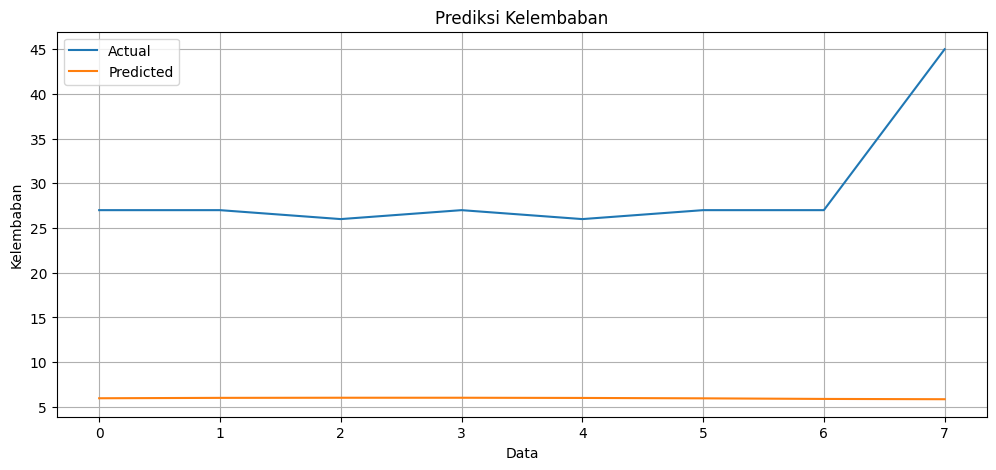

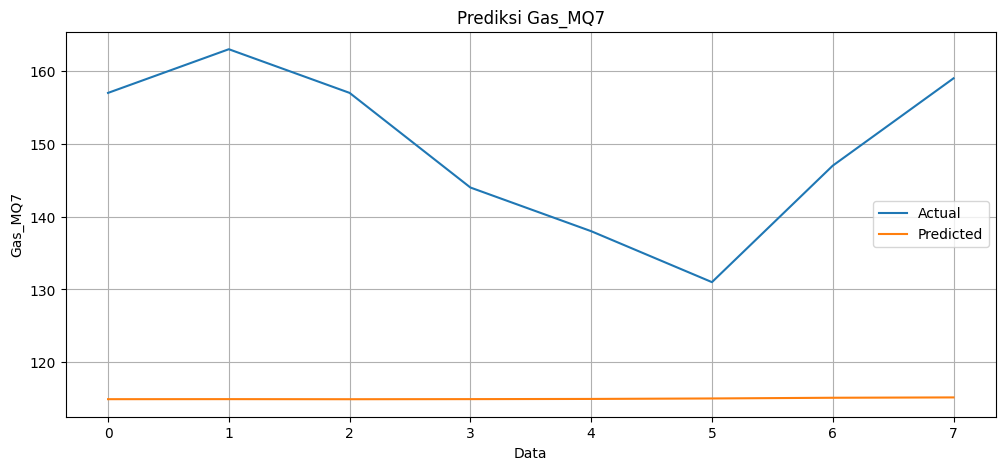

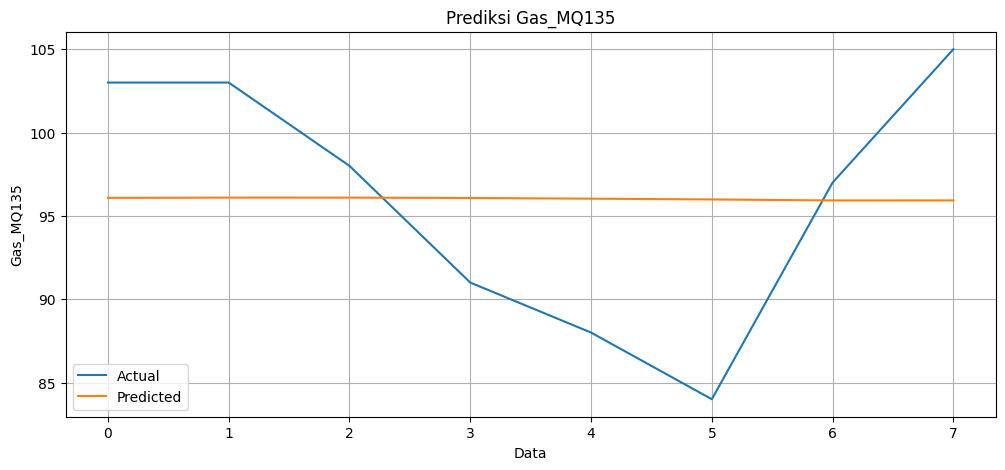

In [17]:
# ======================================
# Prediksi
# ======================================

pred = model.predict(X_test, verbose=0)

# Kembalikan ke nilai asli
pred_real = scaler.inverse_transform(pred)
true_real = scaler.inverse_transform(y_test)

# Nama fitur
feature_names = [
    "Debu",
    "Suhu",
    "Kelembaban",
    "Gas_MQ7",
    "Gas_MQ135"
]

print("="*70)
print("HASIL EVALUASI REGRESI")
print("="*70)

for i in range(5):

    mae = mean_absolute_error(true_real[:, i], pred_real[:, i])
    mse = mean_squared_error(true_real[:, i], pred_real[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(true_real[:, i], pred_real[:, i])

    print(f"\n{feature_names[i]}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

# ======================================
# Grafik
# ======================================

for i in range(5):

    plt.figure(figsize=(12,5))

    plt.plot(true_real[:, i], label="Actual")
    plt.plot(pred_real[:, i], label="Predicted")

    plt.title(f"Prediksi {feature_names[i]}")
    plt.xlabel("Data")
    plt.ylabel(feature_names[i])

    plt.grid(True)
    plt.legend()

    plt.show()

## Contoh Prediksi

In [22]:
features = [
    "suhu",
    "kelembaban",
    "debu",
    "gas_mq7",
    "gas_mq135"
]

feature_index = {
    name: i for i, name in enumerate(features)
}

# ======================================================
# FUNGSI MENENTUKAN KONDISI
# ======================================================

def score_debu(debu):
    if debu <= 50:
        return 0
    elif debu <= 100:
        return 1
    elif debu <= 150:
        return 2
    else:
        return 3


def score_mq7(mq7):
    if mq7 <= 170:
        return 0
    elif mq7 <= 220:
        return 1
    elif mq7 <= 260:
        return 2
    else:
        return 3


def score_mq135(mq135):
    if mq135 <= 110:
        return 0
    elif mq135 <= 140:
        return 1
    elif mq135 <= 170:
        return 2
    else:
        return 3


def air_status(debu, mq7, mq135):

    total = (
        score_debu(debu)
        + score_mq7(mq7)
        + score_mq135(mq135)
    )

    if total <= 2:
        return "Baik"

    elif total <= 5:
        return "Sedang"

    else:
        return "Tidak Sehat"

# ======================================================
# DATA SAAT INI
# ======================================================

current = df.iloc[-1]

current_time = pd.to_datetime(current["waktu"])

current_suhu = float(current["suhu"])
current_kelembaban = float(current["kelembaban"])
current_debu = float(current["debu"])

current_mq7 = int(current["gas_mq7"])
current_mq135 = int(current["gas_mq135"])

current_status = air_status(
    current_debu,
    current_mq7,
    current_mq135
)

# ======================================================
# PREDIKSI
# ======================================================

latest = X[-1].reshape(1, 60, len(features))

future_scaled = model.predict(latest, verbose=0)

# Supaya tidak keluar dari rentang MinMax
future_scaled = np.clip(future_scaled, 0, 1)

future = scaler.inverse_transform(future_scaled)

# ======================================================
# AMBIL HASIL SESUAI URUTAN FITUR
# ======================================================

future_suhu = future[0, feature_index["suhu"]]
future_kelembaban = future[0, feature_index["kelembaban"]]
future_debu = future[0, feature_index["debu"]]

future_mq7 = future[0, feature_index["gas_mq7"]]
future_mq135 = future[0, feature_index["gas_mq135"]]

future_status = air_status(
    future_debu,
    future_mq7,
    future_mq135
)

next_time = current_time + pd.Timedelta(hours=1)

# ======================================================
# HASIL
# ======================================================

print("=" * 60)
print("DATA SAAT INI")
print("=" * 60)

print(f"Waktu        : {current_time}")
print(f"Debu         : {current_debu:.2f}")
print(f"Suhu         : {current_suhu:.2f} °C")
print(f"Kelembaban   : {current_kelembaban:.2f} %")
print(f"MQ7          : {current_mq7}")
print(f"MQ135        : {current_mq135}")
print(f"Status       : {current_status}")

print()

print("=" * 60)
print("PREDIKSI 1 JAM BERIKUTNYA")
print("=" * 60)

print(f"Waktu        : {next_time}")
print(f"Debu         : {future_debu:.2f}")
print(f"Suhu         : {future_suhu:.2f} °C")
print(f"Kelembaban   : {future_kelembaban:.2f} %")
print(f"MQ7          : {future_mq7:.2f}")
print(f"MQ135        : {future_mq135:.2f}")
print(f"Status       : {future_status}")

DATA SAAT INI
Waktu        : 2026-07-14 15:42:21
Debu         : 45.00
Suhu         : 32.90 °C
Kelembaban   : 64.20 %
MQ7          : 159
MQ135        : 105
Status       : Baik

PREDIKSI 1 JAM BERIKUTNYA
Waktu        : 2026-07-14 16:42:21
Debu         : 24.00
Suhu         : 31.23 °C
Kelembaban   : 59.00 %
MQ7          : 115.16
MQ135        : 95.93
Status       : Baik


## Distribusi Kondisi Udara

kondisi
Baik           94
Sedang          5
Tidak Sehat     1
Name: count, dtype: int64


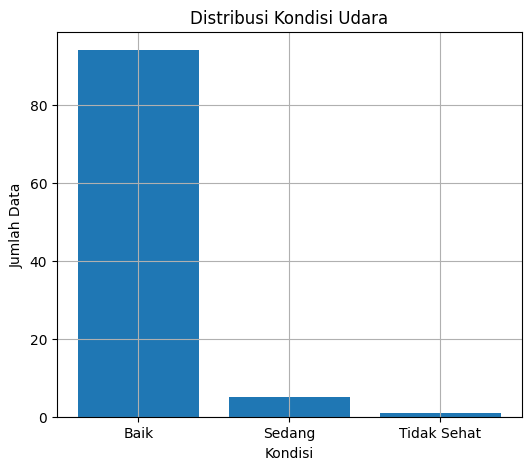

In [23]:
def score_debu(debu):
    if debu <= 50:
        return 0
    elif debu <= 100:
        return 1
    elif debu <= 150:
        return 2
    else:
        return 3


def score_mq7(mq7):
    if mq7 <= 170:
        return 0
    elif mq7 <= 220:
        return 1
    elif mq7 <= 260:
        return 2
    else:
        return 3


def score_mq135(mq135):
    if mq135 <= 110:
        return 0
    elif mq135 <= 140:
        return 1
    elif mq135 <= 170:
        return 2
    else:
        return 3


def air_status(debu, mq7, mq135):

    total = (
        score_debu(debu)
        + score_mq7(mq7)
        + score_mq135(mq135)
    )

    if total <= 2:
        return "Baik"

    elif total <= 5:
        return "Sedang"

    else:
        return "Tidak Sehat"

df["kondisi"] = df.apply(
    lambda x: air_status(
        x["debu"],
        x["gas_mq7"],
        x["gas_mq135"]
    ),
    axis=1
)

print(df["kondisi"].value_counts())

plt.figure(figsize=(6,5))

jumlah = df["kondisi"].value_counts()

plt.bar(
    jumlah.index,
    jumlah.values
)

plt.title("Distribusi Kondisi Udara")

plt.xlabel("Kondisi")
plt.ylabel("Jumlah Data")

plt.grid(True)

plt.show()

## Statistik Fitur

In [25]:
print("="*60)
print("STATISTIK DESKRIPTIF")
print("="*60)

print(df[["debu","suhu","kelembaban", "gas_mq7", "gas_mq135"]].describe())

STATISTIK DESKRIPTIF
             debu        suhu  kelembaban     gas_mq7   gas_mq135
count  100.000000  100.000000  100.000000  100.000000  100.000000
mean    31.480000   30.191000   57.547000  152.200000  100.920000
std     10.470237    3.232008    6.885785   32.886398   15.198804
min     24.000000   24.200000   45.800000  110.000000   76.000000
25%     26.000000   26.700000   50.000000  126.500000   93.750000
50%     27.000000   32.700000   62.200000  157.000000  100.000000
75%     35.250000   33.000000   63.900000  160.000000  103.000000
max    114.000000   33.400000   64.900000  268.000000  151.000000


## Histogram Debu

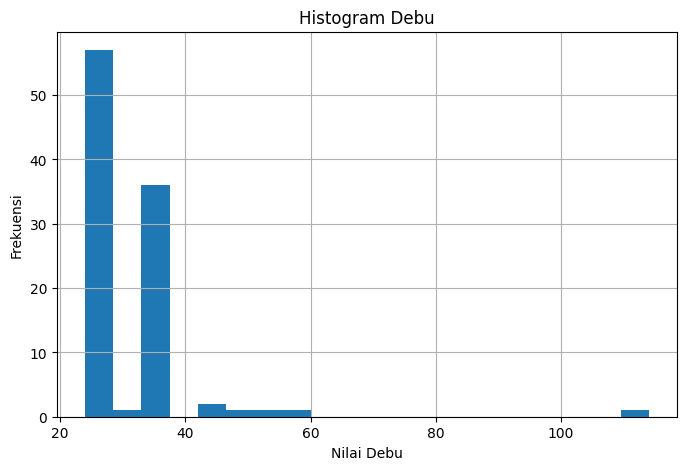

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df["debu"], bins=20)

plt.title("Histogram Debu")
plt.xlabel("Nilai Debu")
plt.ylabel("Frekuensi")

plt.grid(True)

plt.show()

## Histogram Suhu

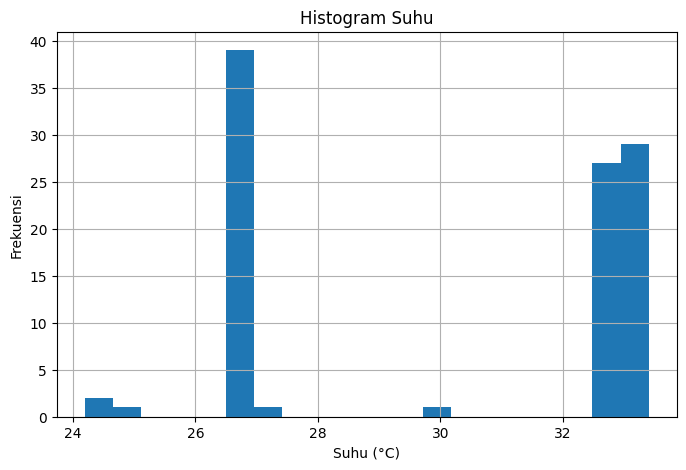

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df["suhu"], bins=20)

plt.title("Histogram Suhu")
plt.xlabel("Suhu (°C)")
plt.ylabel("Frekuensi")

plt.grid(True)

plt.show()

## Histogram Kelembaban

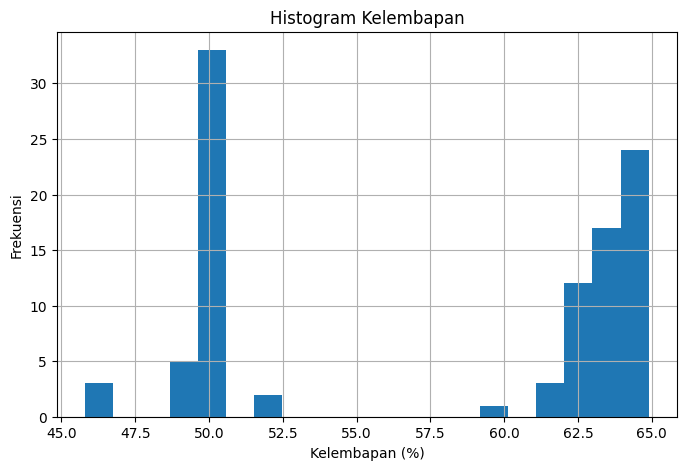

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["kelembaban"], bins=20)

plt.title("Histogram Kelembapan")
plt.xlabel("Kelembapan (%)")
plt.ylabel("Frekuensi")

plt.grid(True)

plt.show()

## Histogram MQ7

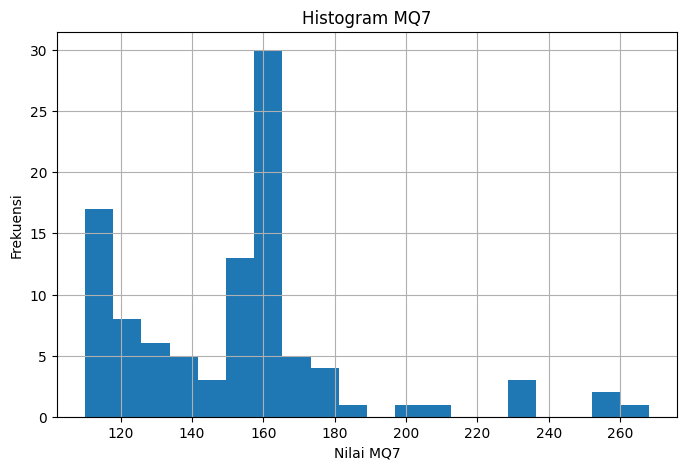

In [30]:
plt.figure(figsize=(8,5))

plt.hist(df["gas_mq7"], bins=20)

plt.title("Histogram MQ7")
plt.xlabel("Nilai MQ7")
plt.ylabel("Frekuensi")

plt.grid(True)

plt.show()

## Histogram MQ135

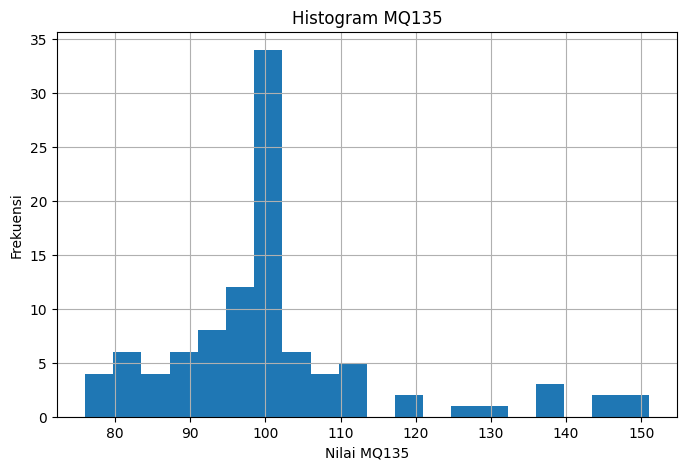

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["gas_mq135"], bins=20)

plt.title("Histogram MQ135")
plt.xlabel("Nilai MQ135")
plt.ylabel("Frekuensi")

plt.grid(True)

plt.show()

## Heatmap Korelasi

                debu      suhu  kelembaban   gas_mq7  gas_mq135
debu        1.000000 -0.090136   -0.113227  0.617141   0.542189
suhu       -0.090136  1.000000    0.991152 -0.225221  -0.091396
kelembaban -0.113227  0.991152    1.000000 -0.233194  -0.088006
gas_mq7     0.617141 -0.225221   -0.233194  1.000000   0.926562
gas_mq135   0.542189 -0.091396   -0.088006  0.926562   1.000000


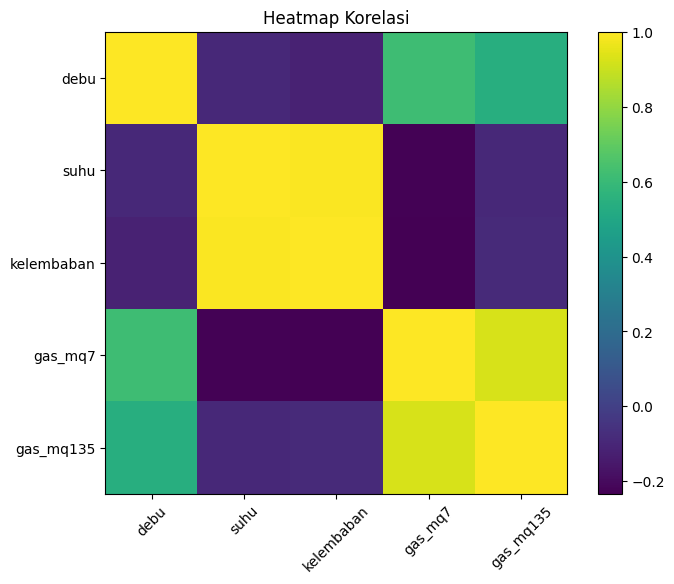

In [32]:
corr = df[
    [
        "debu",
        "suhu",
        "kelembaban",
        "gas_mq7",
        "gas_mq135"
    ]
].corr()

print(corr)

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Heatmap Korelasi")

plt.show()